## **Python scientifique - Projet Base de données** *Spotify*
* Edouard BREMONT edouard.bremont@centrale-med.fr
* Guillaume SURLEAU guillaume.surleau@centrale-med.fr

In [261]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

___
___
#### **PRESENTATION DE LA BASE DE DONNEES**
**Sources** :

Issue de la plateforme **Kaggle** ([lien](https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs/data)) et extraction des données via l'API *Spotify*, la base de données représente les données d'environ 30 000 chansons streamées sur **Spotify**, soient environ 5000 chansons collectées par genre principale de musique (*EDM*, *Latin*, *Pop*, *R&B*, *Rap*, & *Rock*).

In [262]:
data = pd.read_csv("spotify_songs.csv")
data.head(3)

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616


**Description des données** :
- Les lignes (32833 au total) correspondent aux chansons
- les colonnes (23 au total) correspondent aux métadonnées (id, artiste, genre, date de sortie, …) et aux caractéristiques audio des chansons (popularité, dansabilité, tempo, durée, …).

In [263]:
data.shape

(32833, 23)

In [264]:
data.info()
#data.columns.to_list()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

___
___
#### **PARTIE I** - Nettoyage des données

**1) Existence de valeurs manquantes (null)**

Le dataset présente certaines valeurs manquantes (null) dont on doit s'occuper, soient dans les colonnes 'track_name', 'track_artist' et 'track_album_name'.

In [265]:
print(data.isnull().sum())

track_id                    0
track_name                  5
track_artist                5
track_popularity            0
track_album_id              0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_id                 0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
liveness                    0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64


Les 5 lignes sont des cas particuliers (regroupement de plusieurs interprétation d'une chanson) qui ne vont pas être pris en compte dans notre analyse.

In [266]:
lignes_nulles = data[data.isnull().any(axis=1)]
lignes_nulles

df = data.dropna()

**2) Existence de doublons**

Les chansons inscrites plusieurs fois dans le dataset sont supprimées, en se basant sur l'id Spotify de chaque chanson supposé unique.

On vérifie tout de même s'il existe des doublons d'une chanson apparaissant dans des contextes différents (exemple : album ou playlist différents) et on les supprime en gardant la version la plus écoutée.

In [267]:
nb_doublons = df.duplicated(subset=['track_id']).sum()
print(f"Nombre de doublons exacts (ID) : {nb_doublons}")

df = df.drop_duplicates(subset=['track_id'], keep='first')
print(len(df))

df_clean = df.sort_values('track_popularity', ascending=False)

doublons_noms = df_clean.duplicated(subset=['track_name', 'track_artist']).sum()
print(f"Doublons potentiels (Même nom/artiste mais ID différent) : {doublons_noms}")

df_final = df_clean.drop_duplicates(subset=['track_name', 'track_artist'], keep='first')

print(f"Taille finale du dataset : {len(df_final)} chansons uniques.")

Nombre de doublons exacts (ID) : 4476
28352
Doublons potentiels (Même nom/artiste mais ID différent) : 2123
Taille finale du dataset : 26229 chansons uniques.


**3) Traitement des features**

Les colonnes/features qui nous intéressent pas pour l'analyse et la visualisation des données sont supprimées.

In [268]:
df_final = df_final.drop(['playlist_name', 'playlist_id', 'track_album_id', 'track_album_name'], axis=1)
df_final

,track_id,track_name,track_artist,track_popularity,track_album_release_date,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
1551,2XU0oxnq2qxCpomAAuJY8K,Dance Monkey,Tones and I,100,2019-10-17,pop,post-teen pop,0.824,0.588,6,-6.400,0,0.0924,0.69200,0.000104,0.1490,0.513,98.027,209438
20092,696DnlkuDOXcMAnKlTgXXK,ROXANNE,Arizona Zervas,99,2019-10-10,latin,latin hip hop,0.621,0.601,6,-5.616,0,0.1480,0.05220,0.000000,0.4600,0.457,116.735,163636
716,0sf12qNH5qcw8qpgymFOqD,Blinding Lights,The Weeknd,98,2019-11-29,pop,dance pop,0.513,0.796,1,-4.075,1,0.0629,0.00147,0.000209,0.0938,0.345,171.017,201573
5508,0nbXyq5TXYPCO7pr3N8S4I,The Box,Roddy Ricch,98,2019-12-06,rap,hip hop,0.896,0.586,10,-6.687,0,0.0559,0.10400,0.000000,0.7900,0.642,116.971,196653
1301,21jGcNKet2qwijlDFuPiPb,Circles,Post Malone,98,2019-09-06,pop,post-teen pop,0.695,0.762,0,-3.497,1,0.0395,0.19200,0.002440,0.0863,0.553,120.042,215280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9249,7a9KN84HehzsVv1dlbnnNb,Flow,Gzuz,0,2011-01-21,rap,gangster rap,0.506,0.897,11,-5.265,1,0.3980,0.33200,0.000000,0.1170,0.604,109.059,140634
9182,6lk4Nhg2jo5rAh5EYCBH1e,Nuthin But A G Thang,Snoop Dogg,0,2004-03-01,rap,gangster rap,0.818,0.713,11,-8.101,0,0.2830,0.00896,0.000000,0.2640,0.712,94.617,236160
9179,358r2r4JrLyIEhZ8MQVpO7,Ready Or Not,2Pac,0,2017-06-21,rap,gangster rap,0.690,0.629,10,-7.349,0,0.3180,0.52200,0.000000,0.5260,0.212,89.962,209189
9172,7CmZmiCqn9xKG3rLnr1GKD,Old Time's Sake,Eminem,0,2009-05-15,rap,gangster rap,0.775,0.829,1,-1.933,1,0.3040,0.06060,0.000000,0.3300,0.836,176.047,278160


Les colonnes sont renommées pour plus de compréhension et pour plus de facilité d'accès.

In [269]:
df_final = df_final.rename(columns={"track_id":"id", "track_name":"chanson", "track_artist":"artiste", "track_popularity":"popularité", "track_album_release_date":"date_sortie", "playlist_genre":"genre", "playlist_subgenre":"sousgenre", "danceability":"dansabilité", "energy":"énergie", "key":"clé", "loudness":"niveau_sonore", "duration_ms":"ms"})
df_final

,id,chanson,artiste,popularité,date_sortie,genre,sousgenre,dansabilité,énergie,clé,niveau_sonore,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,ms
1551,2XU0oxnq2qxCpomAAuJY8K,Dance Monkey,Tones and I,100,2019-10-17,pop,post-teen pop,0.824,0.588,6,-6.400,0,0.0924,0.69200,0.000104,0.1490,0.513,98.027,209438
20092,696DnlkuDOXcMAnKlTgXXK,ROXANNE,Arizona Zervas,99,2019-10-10,latin,latin hip hop,0.621,0.601,6,-5.616,0,0.1480,0.05220,0.000000,0.4600,0.457,116.735,163636
716,0sf12qNH5qcw8qpgymFOqD,Blinding Lights,The Weeknd,98,2019-11-29,pop,dance pop,0.513,0.796,1,-4.075,1,0.0629,0.00147,0.000209,0.0938,0.345,171.017,201573
5508,0nbXyq5TXYPCO7pr3N8S4I,The Box,Roddy Ricch,98,2019-12-06,rap,hip hop,0.896,0.586,10,-6.687,0,0.0559,0.10400,0.000000,0.7900,0.642,116.971,196653
1301,21jGcNKet2qwijlDFuPiPb,Circles,Post Malone,98,2019-09-06,pop,post-teen pop,0.695,0.762,0,-3.497,1,0.0395,0.19200,0.002440,0.0863,0.553,120.042,215280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9249,7a9KN84HehzsVv1dlbnnNb,Flow,Gzuz,0,2011-01-21,rap,gangster rap,0.506,0.897,11,-5.265,1,0.3980,0.33200,0.000000,0.1170,0.604,109.059,140634
9182,6lk4Nhg2jo5rAh5EYCBH1e,Nuthin But A G Thang,Snoop Dogg,0,2004-03-01,rap,gangster rap,0.818,0.713,11,-8.101,0,0.2830,0.00896,0.000000,0.2640,0.712,94.617,236160
9179,358r2r4JrLyIEhZ8MQVpO7,Ready Or Not,2Pac,0,2017-06-21,rap,gangster rap,0.690,0.629,10,-7.349,0,0.3180,0.52200,0.000000,0.5260,0.212,89.962,209189
9172,7CmZmiCqn9xKG3rLnr1GKD,Old Time's Sake,Eminem,0,2009-05-15,rap,gangster rap,0.775,0.829,1,-1.933,1,0.3040,0.06060,0.000000,0.3300,0.836,176.047,278160


Certains formats des valeurs des colonnes sont modifiés (*'date_sortie'* : on veut seulement l'année de sortie de type entier, *'ms'* : on convertit en min les millisecondes, *'clé+mode'* : on associe les deux caractéristiques) toujours pour une meilleure gestion des données.

In [270]:
df_final['date_sortie'] = df_final['date_sortie'].astype(str).str[:4]
df_final['date_sortie'] = pd.to_numeric(df_final['date_sortie'], errors='coerce')

df_final['decennie'] = ((df_final['date_sortie'] // 10)) * 10

df_final['duree_min'] = df_final['ms'] / 60000

key_mapping = {
    0: 'C', 1: 'C#', 2: 'D', 3: 'D#', 4: 'E', 5: 'F',
    6: 'F#', 7: 'G', 8: 'G#', 9: 'A', 10: 'A#', 11: 'B'
}
df_final['nom_clé'] = df_final['clé'].map(key_mapping)
df_final['tonalité'] = df_final['nom_clé'].astype(str) + ' ' + df_final['mode'].map({1: 'Major', 0: 'Minor'})

df_final = df_final.drop(['mode', 'clé', 'nom_clé', 'ms'], axis=1)
df_final

,id,chanson,artiste,popularité,date_sortie,genre,sousgenre,dansabilité,énergie,niveau_sonore,speechiness,acousticness,instrumentalness,liveness,valence,tempo,decennie,duree_min,tonalité
1551,2XU0oxnq2qxCpomAAuJY8K,Dance Monkey,Tones and I,100,2019,pop,post-teen pop,0.824,0.588,-6.400,0.0924,0.69200,0.000104,0.1490,0.513,98.027,2010,3.490633,F# Minor
20092,696DnlkuDOXcMAnKlTgXXK,ROXANNE,Arizona Zervas,99,2019,latin,latin hip hop,0.621,0.601,-5.616,0.1480,0.05220,0.000000,0.4600,0.457,116.735,2010,2.727267,F# Minor
716,0sf12qNH5qcw8qpgymFOqD,Blinding Lights,The Weeknd,98,2019,pop,dance pop,0.513,0.796,-4.075,0.0629,0.00147,0.000209,0.0938,0.345,171.017,2010,3.359550,C# Major
5508,0nbXyq5TXYPCO7pr3N8S4I,The Box,Roddy Ricch,98,2019,rap,hip hop,0.896,0.586,-6.687,0.0559,0.10400,0.000000,0.7900,0.642,116.971,2010,3.277550,A# Minor
1301,21jGcNKet2qwijlDFuPiPb,Circles,Post Malone,98,2019,pop,post-teen pop,0.695,0.762,-3.497,0.0395,0.19200,0.002440,0.0863,0.553,120.042,2010,3.588000,C Major
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9249,7a9KN84HehzsVv1dlbnnNb,Flow,Gzuz,0,2011,rap,gangster rap,0.506,0.897,-5.265,0.3980,0.33200,0.000000,0.1170,0.604,109.059,2010,2.343900,B Major
9182,6lk4Nhg2jo5rAh5EYCBH1e,Nuthin But A G Thang,Snoop Dogg,0,2004,rap,gangster rap,0.818,0.713,-8.101,0.2830,0.00896,0.000000,0.2640,0.712,94.617,2000,3.936000,B Minor
9179,358r2r4JrLyIEhZ8MQVpO7,Ready Or Not,2Pac,0,2017,rap,gangster rap,0.690,0.629,-7.349,0.3180,0.52200,0.000000,0.5260,0.212,89.962,2010,3.486483,A# Minor
9172,7CmZmiCqn9xKG3rLnr1GKD,Old Time's Sake,Eminem,0,2009,rap,gangster rap,0.775,0.829,-1.933,0.3040,0.06060,0.000000,0.3300,0.836,176.047,2000,4.636000,C# Major


Enfin, certain type des valeurs des colonnes sont convertis pour optimiser l'accès et l'analyse des données.

In [271]:
df_final['date_sortie'] = df_final['date_sortie'].astype(int)

df_final['genre'] = df_final['genre'].astype('category')
df_final['sousgenre'] = df_final['sousgenre'].astype('category')

cols_textuelles = df_final.select_dtypes(include=['object']).columns
df_final[cols_textuelles] = df_final[cols_textuelles].astype("string")

df_final.info()
#df_final.columns.to_list()

<class 'pandas.core.frame.DataFrame'>
Index: 26229 entries, 1551 to 9171
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   id                26229 non-null  string  
 1   chanson           26229 non-null  string  
 2   artiste           26229 non-null  string  
 3   popularité        26229 non-null  int64   
 4   date_sortie       26229 non-null  int64   
 5   genre             26229 non-null  category
 6   sousgenre         26229 non-null  category
 7   dansabilité       26229 non-null  float64 
 8   énergie           26229 non-null  float64 
 9   niveau_sonore     26229 non-null  float64 
 10  speechiness       26229 non-null  float64 
 11  acousticness      26229 non-null  float64 
 12  instrumentalness  26229 non-null  float64 
 13  liveness          26229 non-null  float64 
 14  valence           26229 non-null  float64 
 15  tempo             26229 non-null  float64 
 16  decennie          26229 n

In [272]:
#la base de données après nettoyage
df_final.head(5)

,id,chanson,artiste,popularité,date_sortie,genre,sousgenre,dansabilité,énergie,niveau_sonore,speechiness,acousticness,instrumentalness,liveness,valence,tempo,decennie,duree_min,tonalité
1551,2XU0oxnq2qxCpomAAuJY8K,Dance Monkey,Tones and I,100,2019,pop,post-teen pop,0.824,0.588,-6.400,0.0924,0.69200,0.000104,0.1490,0.513,98.027,2010,3.490633,F# Minor
20092,696DnlkuDOXcMAnKlTgXXK,ROXANNE,Arizona Zervas,99,2019,latin,latin hip hop,0.621,0.601,-5.616,0.1480,0.05220,0.000000,0.4600,0.457,116.735,2010,2.727267,F# Minor
716,0sf12qNH5qcw8qpgymFOqD,Blinding Lights,The Weeknd,98,2019,pop,dance pop,0.513,0.796,-4.075,0.0629,0.00147,0.000209,0.0938,0.345,171.017,2010,3.359550,C# Major
5508,0nbXyq5TXYPCO7pr3N8S4I,The Box,Roddy Ricch,98,2019,rap,hip hop,0.896,0.586,-6.687,0.0559,0.10400,0.000000,0.7900,0.642,116.971,2010,3.277550,A# Minor
1301,21jGcNKet2qwijlDFuPiPb,Circles,Post Malone,98,2019,pop,post-teen pop,0.695,0.762,-3.497,0.0395,0.19200,0.002440,0.0863,0.553,120.042,2010,3.588000,C Major


___
___
#### **PARTIE II** - Analyse et visualisation des données

___
**OBSERVATIONS GENERALES DU DATASET**

**1) La date de sortie des morceaux** (feature *'date_sortie'*)

En regardant les données qu'on a sur les dates de sortie des morceaux (ci-dessous), on voit que le dataset couvre 63 ans d'histoire de la musique (1957 à 2020).

In [273]:
df_final.date_sortie.describe()

,date_sortie
count,26229.000000
mean,2011.414503
std,11.083658
min,1957.000000
25%,2009.000000
50%,2016.000000
75%,2019.000000
max,2020.000000


Le dataset est **massivement composé de musiques modernes** :

- la **moitié** de tes chansons ont été publiées **entre 2016 et 2020** (médiane à 2016)
- **25%** des morceaux du dataset date seulement **de 2019 et 2020** (3ème Quartile à 2019)

Avec un **écart-type (std) de 11 ans**, la dispersion est relativement faible par rapport à l'étendue totale, confirmant que les données "anciennes" (avant 2000) sont des exceptions (outliers) dans ce dataset.



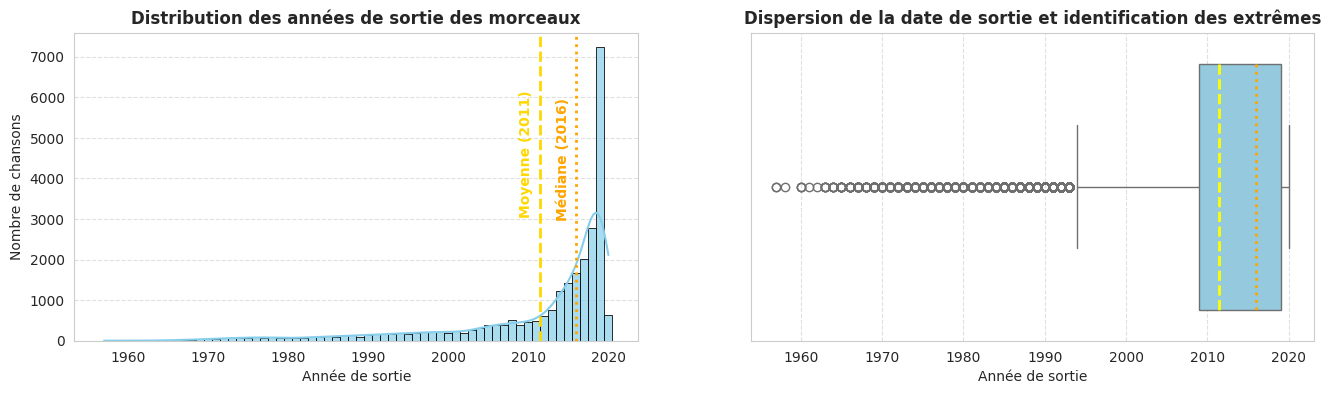

In [274]:
fig, (ax2, ax1) = plt.subplots(1, 2, figsize=(16, 4))

sb.boxplot(x=df_final['date_sortie'],
           color='skyblue',
           ax=ax1,
           showmeans=True,
           meanline=True,
           medianprops={'color': 'orange', 'linestyle':':', 'linewidth': 2},
           meanprops={'color': 'yellow', 'linestyle': '--', 'linewidth': 2})
ax1.set_title('Dispersion de la date de sortie et identification des extrêmes', fontsize=12, fontweight='bold')
ax1.set_xlabel('Année de sortie')

mean_val = df_final['date_sortie'].mean()
median_val = df_final['date_sortie'].median()

sb.histplot(df_final['date_sortie'], discrete=True, kde=True, color='skyblue', edgecolor='black', alpha=0.7, ax=ax2)

ax2.axvline(mean_val, color='gold', linestyle='--', linewidth=2)
ax2.axvline(median_val, color='orange', linestyle=':', linewidth=2)

y_pos = ax2.get_ylim()[1] * 0.4

ax1.grid(False)
ax1.xaxis.grid(True, linestyle='--', alpha=0.6)
ax2.grid(False)
ax2.yaxis.grid(True, linestyle='--', alpha=0.6)

ax2.text(mean_val - 0.8, y_pos, f"Moyenne ({mean_val:.0f})",
         color='gold',
         rotation=90,
         fontweight='bold',
         va='bottom',
         ha='right')


ax2.text(median_val - 0.8, y_pos, f"Médiane ({median_val:.0f})",
         color='orange',
         rotation=90,
         fontweight='bold',
         ha='right')

ax2.set_title('Distribution des années de sortie des morceaux', fontsize=12, fontweight='bold')
ax2.set_xlabel('Année de sortie')
ax2.set_ylabel('Nombre de chansons')

plt.show()

**2) La durée des morceaux** (feature *'duree_min'*)

In [275]:
df_final.duree_min.describe()

,duree_min
count,26229.000000
mean,3.758440
std,1.021504
min,0.066667
25%,3.111283
50%,3.596000
75%,4.230667
max,8.630167


La plupart des morceaux du dataset ont une durée comprise entre 3 et 4 minutes.

Cas extrêmes :
- Les morceaux de durée **inférieur 1.5 min** sont souvent des intros d'albums ou des morceaux de Punk/Grindcore.

- Les morceaux de durée **supérieur à 7 min** s'agissent probablement de "Extended Mix" en EDM ou de morceaux de Rock classique/Jazz.

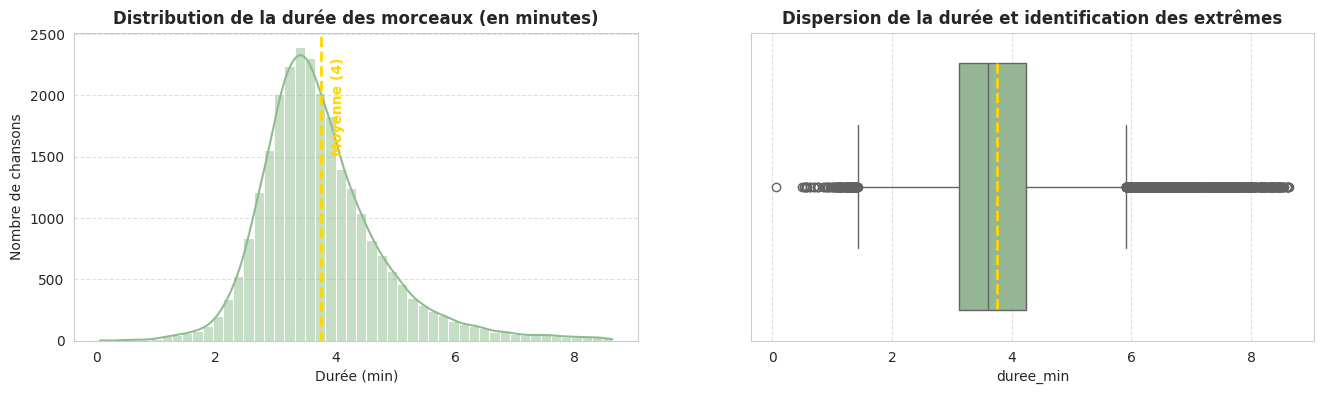

In [276]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
sb.histplot(df_final['duree_min'], bins=50, kde=True, color='darkseagreen', ax=ax1)
sb.boxplot(x=df_final['duree_min'],
           color='darkseagreen',
           ax=ax2,
           showmeans=True,
           meanline=True,
           meanprops={'color': 'gold', 'linestyle': '--', 'linewidth': 2})

y_pos = ax1.get_ylim()[1] * 0.6

ax2.grid(False)
ax2.xaxis.grid(True, linestyle='--', alpha=0.6)
ax1.grid(False)
ax1.yaxis.grid(True, linestyle='--', alpha=0.6)

mean_val = df_final['duree_min'].mean()
ax1.text(mean_val + 0.4, y_pos, f"Moyenne ({mean_val:.0f})",
         color='gold',
         rotation=90,
         fontweight='bold',
         va='bottom',
         ha='right')

ax1.axvline(df_final['duree_min'].mean(), color='gold', linestyle='--', linewidth=2, label=f"Moyenne: {df_final['duree_min'].mean():.2f} min")
ax1.set_title('Distribution de la durée des morceaux (en minutes)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Durée (min)')
ax1.set_ylabel('Nombre de chansons')

ax2.set_title('Dispersion de la durée et identification des extrêmes', fontsize=12, fontweight='bold')
plt.show()


**3) Le genre des morceaux** (features *'genre'* et *'sousgenre'*)

En observant la répartition des chansons dans les genres, on trouve un dataset plutôt équilibré (plus de 3500 morceaux dans chaque genre).

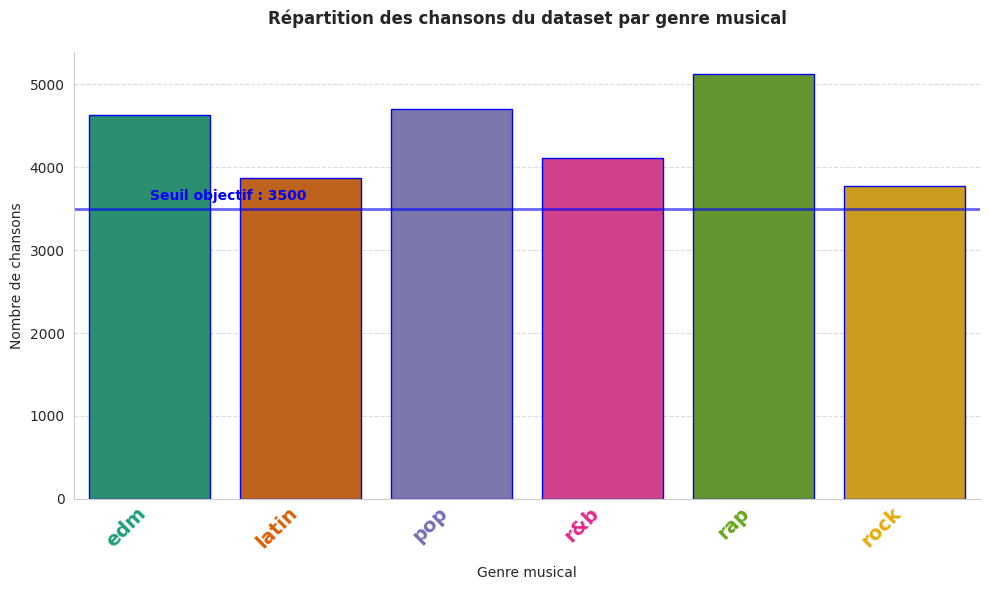

In [277]:
import matplotlib.pyplot as plt
import seaborn as sb

genres = df_final['genre'].value_counts()
plt.figure(figsize=(10, 6))
ax = plt.gca()

color_set = plt.cm.Dark2.colors
nb_genres = len(genres)

couleurs_barres = [color_set[i % len(color_set)] for i in range(nb_genres)]

sb.barplot(
    x=genres.index,
    y=genres.values,
    hue=genres.index,
    palette=couleurs_barres,
    legend=False,
    ax=ax,
    edgecolor='blue'
)

plt.axhline(y=3500, color='blue', linestyle='-', linewidth=2, alpha=0.6)
plt.text(x=0, y=3600, s='Seuil objectif : 3500', color='blue', fontweight='bold', fontsize=10)

plt.xticks(rotation=45, ha='right')
ax.tick_params(axis='x', length=0)

xtick_labels = ax.get_xticklabels()
for i, label in enumerate(xtick_labels):
    color = couleurs_barres[i]
    label.set_color(color)
    label.set_fontweight('bold')
    label.set_fontsize(14)

plt.title('Répartition des chansons du dataset par genre musical', fontsize=12, fontweight='bold', pad=20)
plt.xlabel('Genre musical', fontsize=10, labelpad=10)
plt.ylabel('Nombre de chansons', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Pour plus de détails, on visualise la composition de chaque genre en sous-genres présent dans le dataset.

In [278]:
import warnings
import plotly.express as px

# Suppress the specific FutureWarning from pandas/plotly
warnings.filterwarnings("ignore", category=FutureWarning, module="plotly.express._core")

# Your existing code
treemap_df = df_final.groupby(['genre', 'sousgenre'], observed=True).size().reset_index(name='nombre_de_chansons')

fig = px.treemap(
    treemap_df,
    path=['genre', 'sousgenre'],
    values='nombre_de_chansons',
    color='genre',
    title='Distribution hiérarchique des Genres et Sous-genres',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

fig.show()

Si on s'intéresse au marché musical de chaque décennie **pour ce dataset**, on observe :
- une dominance incontestable (**pic à 90 % du dataset**) du genre **rock sur 4 années (1950 à 1980)**.
- l'**edm**, très peu représenté avant, connaît une **grande croissance après l'an 2000**.
- **Après 1970** : le rock perd sa grande influence et donne place au **r&b** et au **rap en 1990**.
- **Après 2020** : le rock est devenu l'un des genres les moins représentés (sous les 10 %) mais le **marché est devenu beaucoup plus équilibré** entre tous les genres avec la **pop qui termine en tête**.

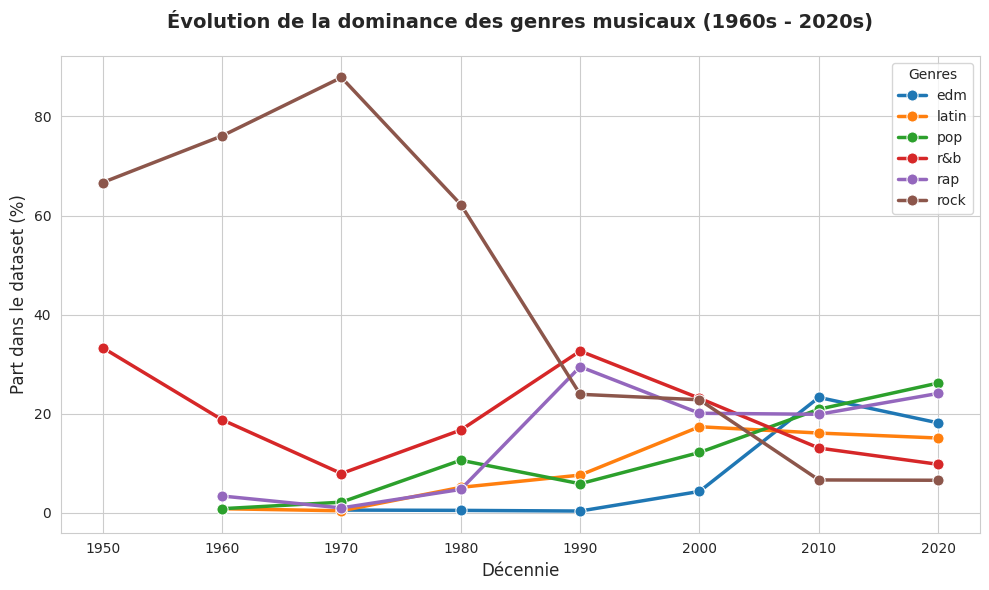

In [279]:
#Calcul le nombre de chansons par décennie et par genre
genre_evo = df_final.groupby(['decennie', 'genre'], observed=True).size().reset_index(name='nombre')

#Transforme en pourcentage pour compenser le biais de volume des années récentes
# On divise le nombre de chansons d'un genre par le total de la décennie
total_par_decennie = genre_evo.groupby('decennie')['nombre'].transform('sum')
genre_evo['pourcentage'] = (genre_evo['nombre'] / total_par_decennie) * 100

plt.figure(figsize=(10, 6))
sb.set_style("whitegrid")

plot = sb.lineplot(
    data=genre_evo,
    x='decennie',
    y='pourcentage',
    hue='genre',
    marker='o',
    markersize=8,
    linewidth=2.5
)

plt.title('Évolution de la dominance des genres musicaux (1960s - 2020s)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Décennie', fontsize=12)
plt.ylabel('Part dans le dataset (%)', fontsize=12)
plt.legend(title='Genres', loc='upper right')
plt.xticks(genre_evo['decennie'].unique())

plt.tight_layout()
plt.show()

**4) La "Température" du dataset** (feature *'popularité'*)

En interprêtant la **distribution de la popularité des chansons** pour comprendre la structure du dataset ("Hits isolés" ou de "Discographies complètes") :
- le dataset contient beaucoup de morceaux **très peu écoutés ou très récents qui n'ont pas encore de score**.
- la **courbe en "Cloche"** (distribution normale) montre que le dataset est **équilibré**, signe d'une base de données représentative du catalogue général de Spotify.
- il y a trop de **morceaux à "0"** pour la construire de futurs modèles de prédiction qui **risquent d'être biaisés**.

In [280]:
print(df_final['popularité'].describe())

count    26229.000000
mean        40.448664
std         23.230227
min          0.000000
25%         24.000000
50%         43.000000
75%         58.000000
max        100.000000
Name: popularité, dtype: float64


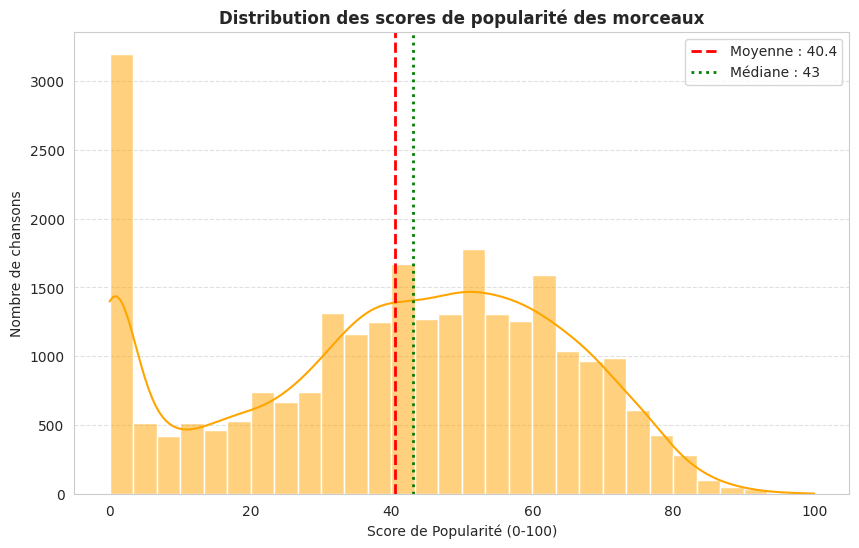

In [281]:
plt.figure(figsize=(10, 6))

# histogramme avec courbe de densité (KDE)
sb.histplot(df_final['popularité'], bins=30, kde=True, color='orange', edgecolor='white')

# indicateurs statistiques (Moyenne et Médiane)
plt.axvline(df_final['popularité'].mean(), color='red', linestyle='--', linewidth=2, label=f"Moyenne : {df_final['popularité'].mean():.1f}")
plt.axvline(df_final['popularité'].median(), color='green', linestyle=':', linewidth=2, label=f"Médiane : {df_final['popularité'].median():.0f}")

plt.grid(False)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.title('Distribution des scores de popularité des morceaux', fontsize=12, fontweight='bold')
plt.xlabel('Score de Popularité (0-100)')
plt.ylabel('Nombre de chansons')
plt.legend()
plt.show()

**5) La Concentration des artistes** (feature *'artiste'*)

Pour bien comprendre la répartition des artistes selon leur nombre de chanson, il nous faut extraire le nombre total d'artistes uniques présents dans le dataset.

In [282]:
artist_counts = df_final['artiste'].value_counts()

# Définition des tranches (bins) pour classer ces fréquences
bins = [0, 1, 5, 10, 20, artist_counts.max()]
labels = ['1 chanson', '2 à 5', '6 à 10', '11 à 20', 'Plus de 20']

# Création de la distribution
distribution_artistes = pd.cut(artist_counts, bins=bins, labels=labels).value_counts().sort_index()

# Calcul du pourcentage pour l'analyse
total_artistes = len(artist_counts)
print(f"Nombre total d'artistes uniques : {total_artistes}")

Nombre total d'artistes uniques : 10692


On trouve que plus de 60% des artistes n'ont qu'une chanson : Le dataset est une collection de morceaux variés, très axée "playlist". C'est excellent pour une analyse de tendances générales.

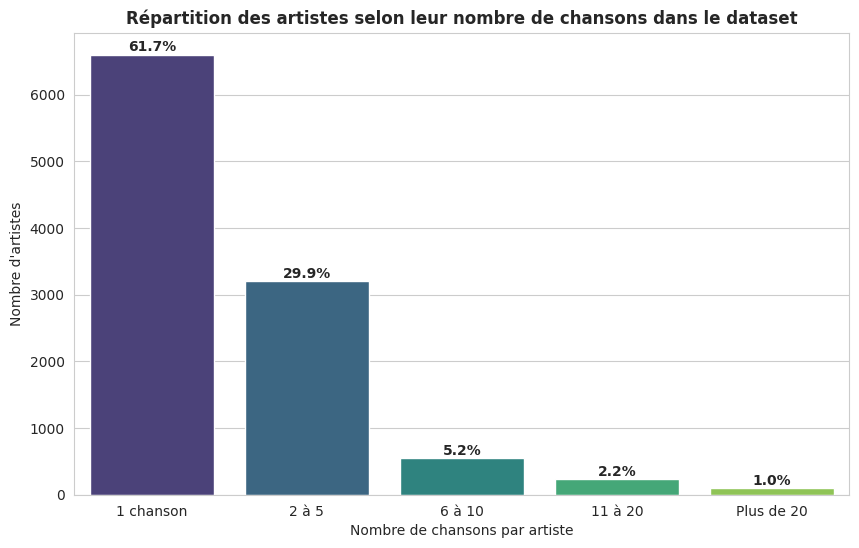

In [283]:
plt.figure(figsize=(10, 6))
sb.barplot(x=distribution_artistes.index, y=distribution_artistes.values, palette="viridis", hue=distribution_artistes.index)

# Ajout des labels de données (pourcentages)
for i, v in enumerate(distribution_artistes.values):
    pct = (v / total_artistes) * 100
    plt.text(i, v + 50, f"{pct:.1f}%", ha='center', fontweight='bold')

plt.title("Répartition des artistes selon leur nombre de chansons dans le dataset", fontsize=12, fontweight='bold')
plt.xlabel("Nombre de chansons par artiste")
plt.ylabel("Nombre d'artistes")
plt.show()

Avec un ratio de concentration des 10 premiers artistes de seulement 2,42 %, le dataset présente une structure extrêmement diversifiée. Cette fragmentation confirme que nous travaillons sur un catalogue de type "bibliothèque" ou "recherche globale" plutôt que sur une collection centrée sur quelques discographies majeures.

In [284]:
total_chansons = len(df_final)

top_10_sum = artist_counts.head(10).sum()
concentration_ratio = (top_10_sum / total_chansons) * 100

print(f"Les 10 artistes les plus présents représentent {concentration_ratio:.2f}% du dataset.")

Les 10 artistes les plus présents représentent 2.42% du dataset.


**6) Classement des chansons, artistes et genres construits à partir du dataset.** (visualisation)

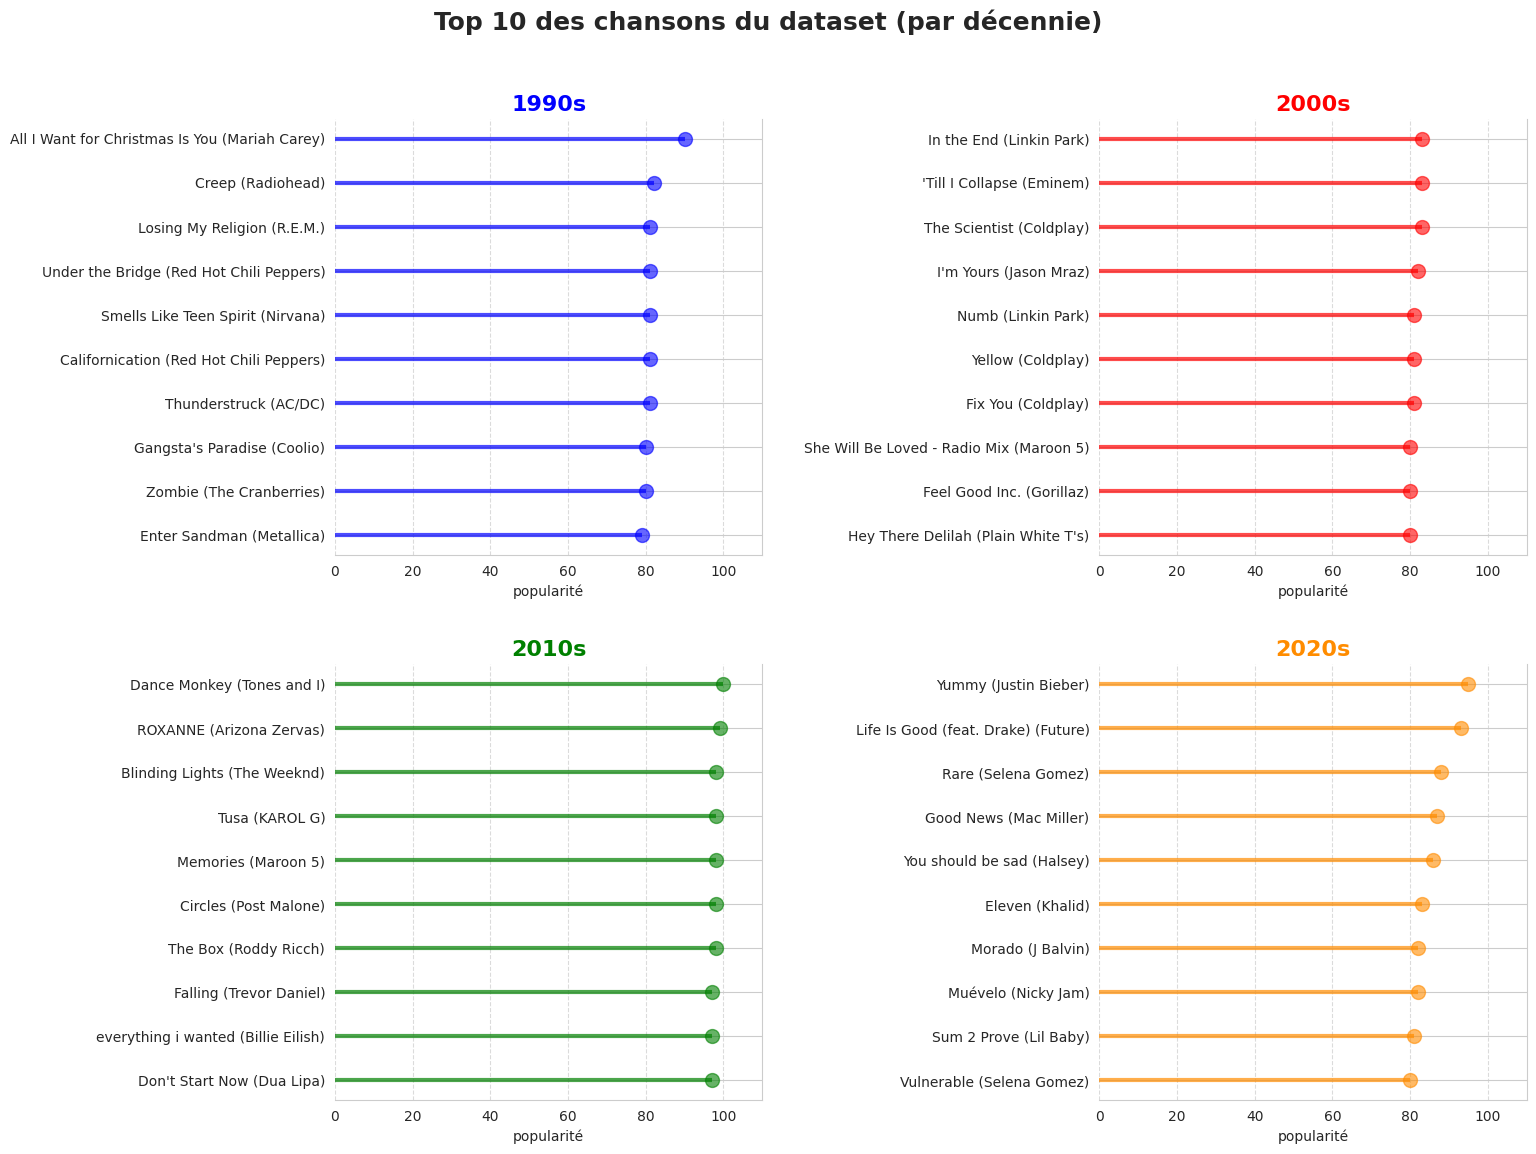

In [285]:
decennies = [1990, 2000, 2010, 2020]
couleurs = ['blue', 'red', 'green', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), layout="tight")
axes = axes.flatten()

for i, dec in enumerate(decennies):
    # Filtrage par décennie, trier par popularité et prendre les 10 premières
    top_songs_dec = (df_final[df_final['decennie'] == dec]
                     .sort_values(by='popularité', ascending=True)
                     .tail(10)
                     .copy()) # .copy() pour éviter les warnings lors de la création de colonne

    top_songs_dec['label_complet'] = top_songs_dec['chanson'] + " (" + top_songs_dec['artiste'] + ")"

    ax = axes[i]

    ax.hlines(y=top_songs_dec['label_complet'],
              xmin=0,
              xmax=top_songs_dec['popularité'],
              color=couleurs[i],
              alpha=0.7,
              linewidth=3)

    ax.plot(top_songs_dec['popularité'],
            top_songs_dec['label_complet'],
            "o",
            markersize=10,
            color=couleurs[i],
            alpha=0.6)

    ax.set_title(f'{dec}s', fontsize=16, fontweight='bold', color=couleurs[i])
    ax.set_xlabel('popularité' , fontsize=10)
    ax.set_ylabel('')
    ax.set_xlim(0, 110)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)


plt.suptitle('Top 10 des chansons du dataset (par décennie)', fontsize=18, fontweight='bold')
plt.tight_layout(pad=3.0)
plt.show()

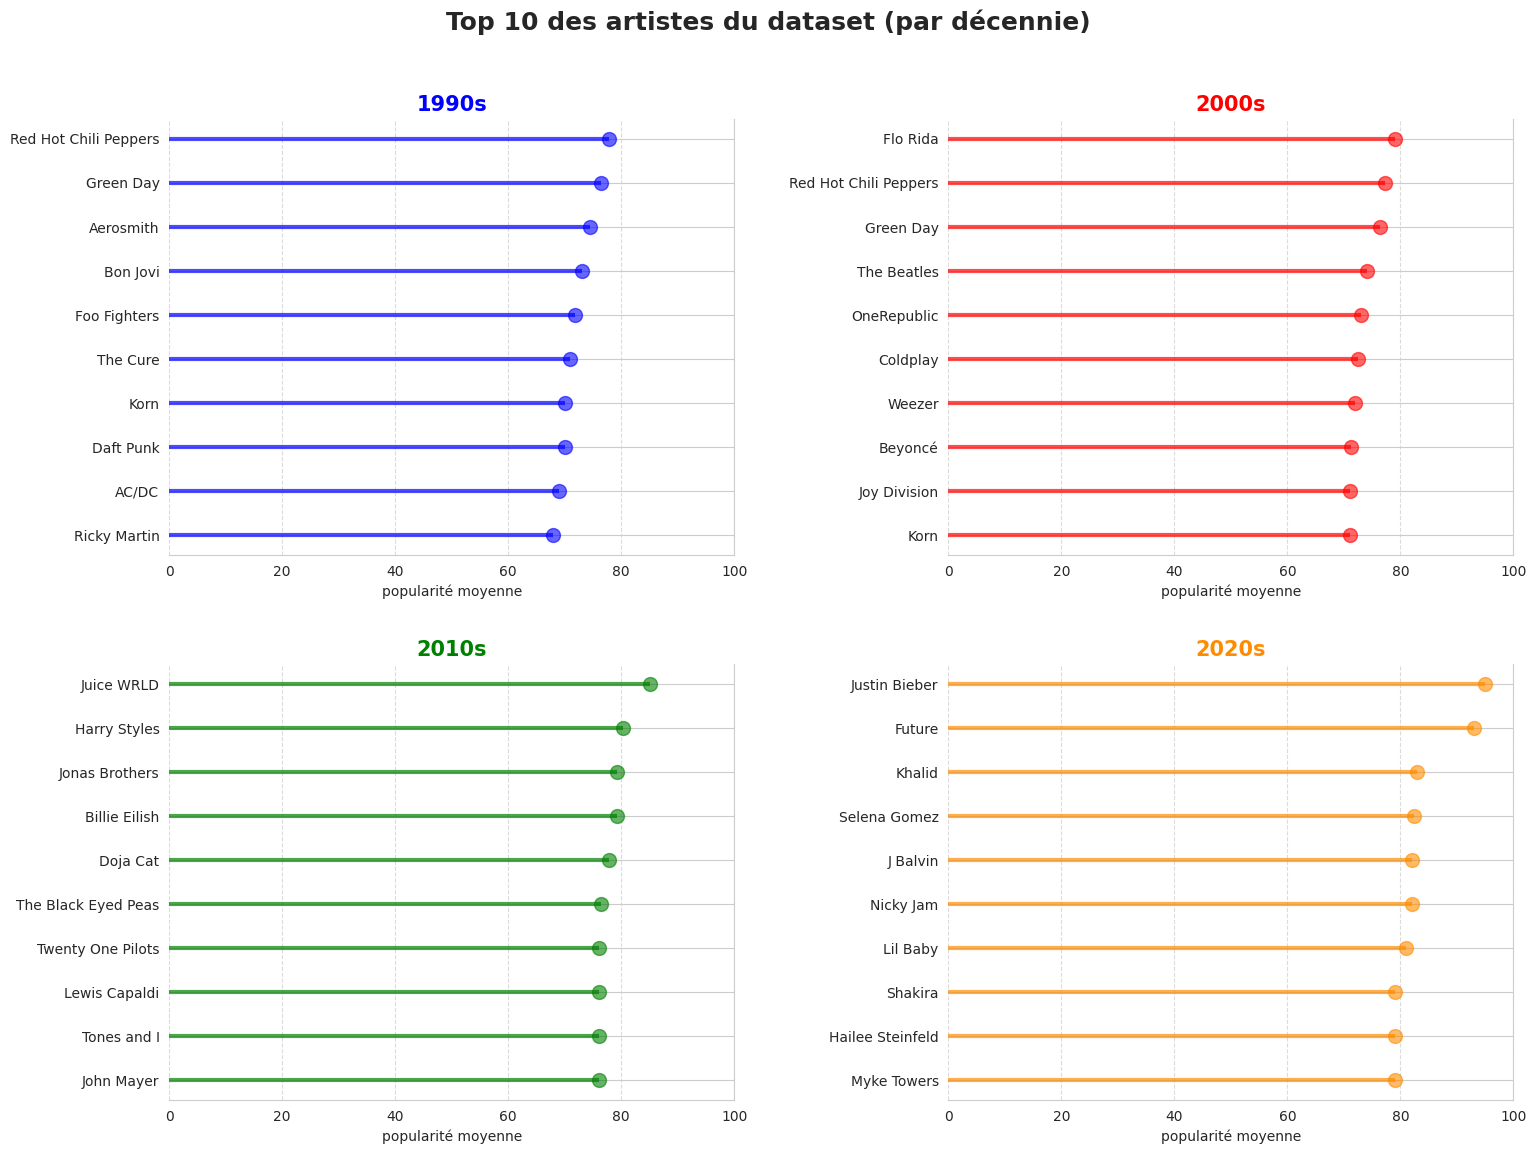

In [286]:
counts = df_final['artiste'].value_counts()
artistes_retenus = counts[counts >= 7].index
df_filtre = df_final[df_final['artiste'].isin(artistes_retenus)]

decennies = [1990, 2000, 2010, 2020]
couleurs = ['blue', 'red', 'green', 'darkorange']

fig, axes = plt.subplots(2, 2, figsize=(16, 12), layout="tight")
axes = axes.flatten() # On aplatit la matrice d'axes pour boucler facilement dessus

for i, dec in enumerate(decennies):
    # Extraction du top 10 pour la décennie actuelle
    top_data = (df_filtre[df_filtre['decennie'] == dec]
                .groupby('artiste')['popularité']
                .mean()
                .sort_values(ascending=True)
                .tail(10))

    ax = axes[i]

    ax.hlines(y=top_data.index, xmin=0, xmax=top_data.values,
              color=couleurs[i], alpha=0.7, linewidth=3)
    ax.plot(top_data.values, top_data.index, "o",
            markersize=10, color=couleurs[i], alpha=0.6)

    ax.set_title(f'{dec}s', fontsize=15, fontweight='bold', color=couleurs[i])
    ax.set_xlabel('popularité moyenne', fontsize=10)
    ax.set_xlim(0, 100)
    ax.grid(axis='x', linestyle='--', alpha=0.7)
    ax.spines['left'].set_visible(False)
    ax.spines['top'].set_visible(False)

plt.suptitle('Top 10 des artistes du dataset (par décennie)', fontsize=18, fontweight='bold')
plt.tight_layout(pad=3.0)
plt.show()

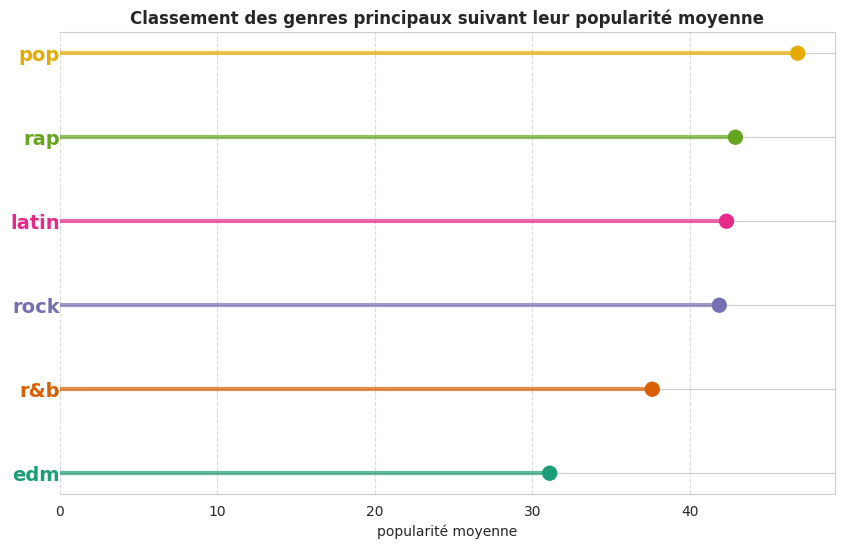

In [287]:
classement_genres = df_final.groupby('genre', observed=True)['popularité'].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 6))
ax = plt.gca()

palette_set = plt.cm.Dark2.colors
nb_genres = len(classement_genres)
couleurs_points = [palette_set[i % len(palette_set)] for i in range(nb_genres)]


ax.hlines(y=classement_genres.index,
           xmin=0,
           xmax=classement_genres.values,
           color=couleurs_points,
           linewidth=3,
           alpha=0.7)

ax.scatter(classement_genres.values,
            classement_genres.index,
            c=couleurs_points,
            s=100,
            zorder=3)

labels = ax.get_yticklabels()
ax.tick_params(axis='y',
               length=0,
               labelsize=14)

for label, color in zip(labels, couleurs_points):
    label.set_color(color)
    label.set_fontweight('bold')

ax.set_xlim(left=0)
ax.tick_params(axis='y', pad=0)
ax.spines['left'].set_visible(False)

plt.title('Classement des genres principaux suivant leur popularité moyenne', fontsize=12, fontweight='bold')
plt.xlabel('popularité moyenne', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

___
**ANALYSE DES CARACTERISTIQUES AUDIO**

**1) La durée des morceaux au fil des années**

L'évolution de la durée des morceaux au fil des années est intéressante :
- **Chute après 2014-2015** représentatif de l'**effet "Streaming"** : les artistes produisent des morceaux plus courts pour augmenter le nombre d'écoutes (un morceau de 2 minutes rapporte autant qu'un morceau de 10 minutes).
- La ligne de régression descendante confirmera visuellement que les **chansons sont de plus en plus courtes** pour s'adapter aux modes de consommation du streaming.

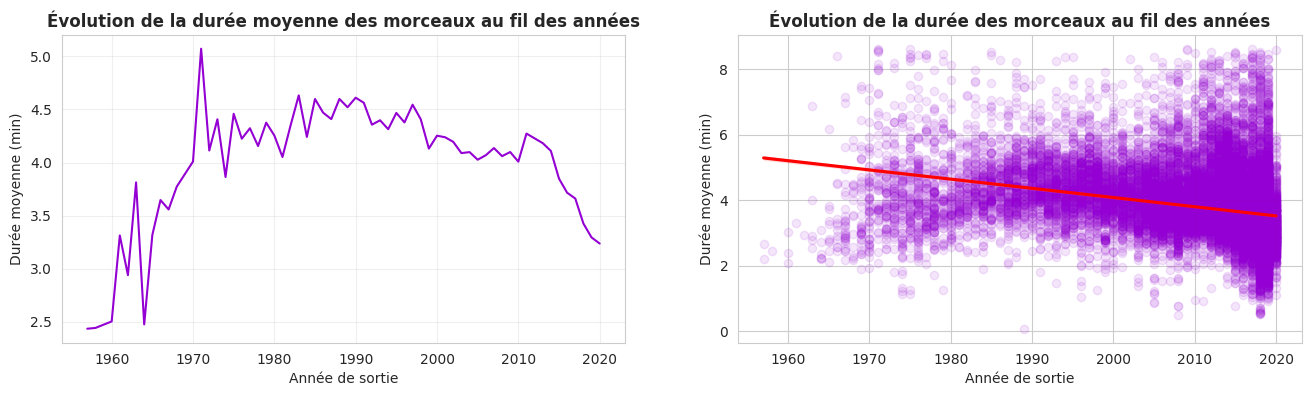

In [288]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
# On utilise lineplot qui calcule automatiquement la moyenne par année
sb.lineplot(data=df_final, x='date_sortie', ax=ax1, y='duree_min', color='darkviolet', errorbar=None)

ax1.set_title('Évolution de la durée moyenne des morceaux au fil des années', fontweight='bold')
ax1.set_xlabel('Année de sortie')
ax1.set_ylabel('Durée moyenne (min)')
ax1.grid(True, alpha=0.3)

# Optionnel : Scatter Regression pour la durée au fil du temps
sb.regplot(data=df_final, x='date_sortie', ax=ax2, y='duree_min', scatter_kws={'alpha':0.1}, line_kws={'color':'red'}, color='darkviolet')
ax2.set_title('Évolution de la durée des morceaux au fil des années', fontweight='bold')
ax2.set_ylabel('Durée moyenne (min)')
ax2.set_xlabel('Année de sortie')
plt.show()

**2) L'influence des caractéristiques audio entre-elles**

La matrice de corrélation des caractéristiques audio confirme des intuitions musicales plutôt réelles :
- Lien fort entre **Énergie et Niveau Sonore (0.69)** : reflète la réalité de la production moderne (la "Loudness War") où l'on augmente le volume pour donner une impression de puissance et d'énergie.
- Opposition entre **Acoustique et Énergie (-0.55)** : la logique dit que les instruments acoustiques (piano solo, guitare classique) sont souvent associés à des morceaux plus calmes, tandis que l'énergie est portée par des instruments électriques ou électroniques (synthétiseurs, batteries compressées)
- Lien modéré entre **Dansabilité et Valence (0.33)** : Les gens ont tendance à danser sur des morceaux qui sonnent de manière "heureuse" et inversement.
- La **"Neutralité" de la Popularité (entre -0.14 et 0.09)** : étonnament, cela prouve qu'il n'y a pas de recette magique. On ne devient pas populaire simplement en augmentant le tempo, l'énergie ou la dansabilité. Des facteurs externes rentrent en compte (réseaux, marketing, image de l'artiste).

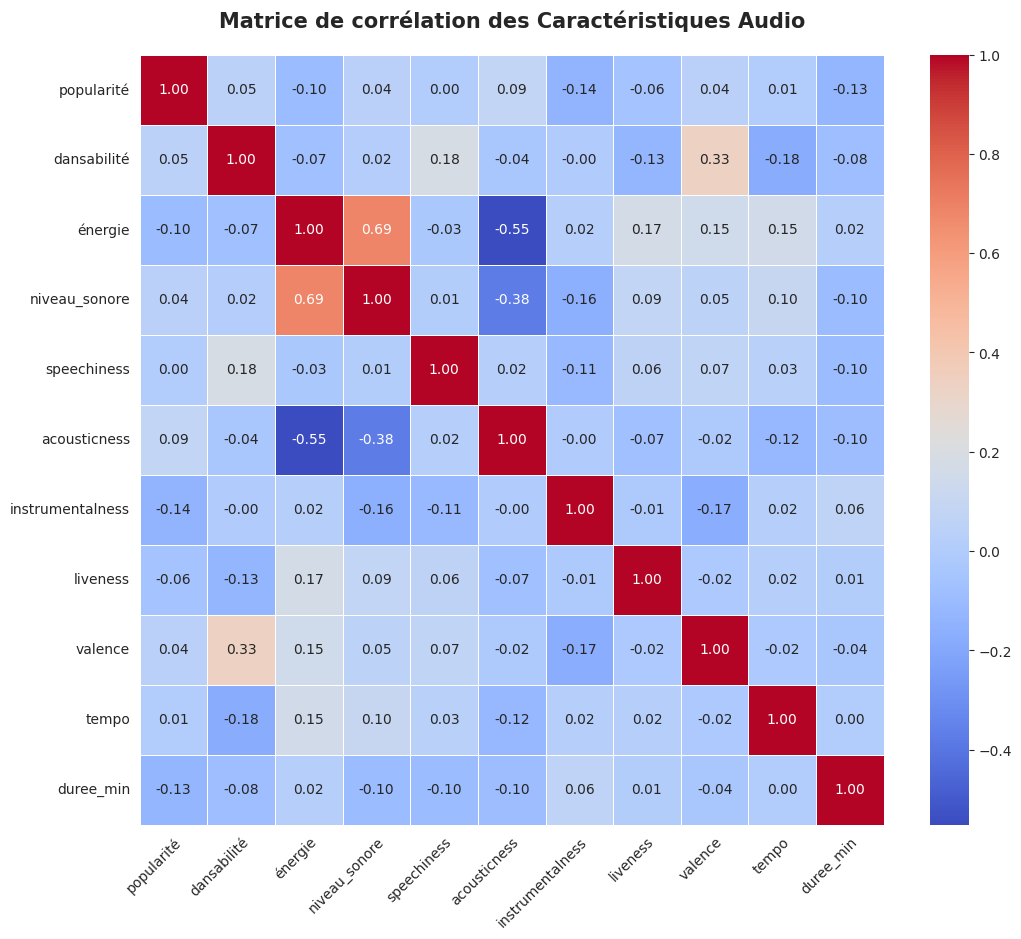

In [289]:
# Sélection des colonnes numériques pour la corrélation
cols_tech = ['popularité', 'dansabilité', 'énergie', 'niveau_sonore',
             'speechiness', 'acousticness', 'instrumentalness',
             'liveness', 'valence', 'tempo', 'duree_min']

corr_matrix = df_final[cols_tech].corr()

# Tracé de la matrice de corrélation
plt.figure(figsize=(12, 10))
sb.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.xticks(rotation=45, ha='right', rotation_mode='anchor')
plt.title('Matrice de corrélation des Caractéristiques Audio', fontsize=15, fontweight='bold', pad=20)
plt.show()

**3) La recherche de critères de succès ('Hits vs Inconnus/Méconnus)**

**Caractéristiques audio** :
- **dansabilité (médiane 'Hits' à O.7 contre 0.65**): la boite est plus haute pour les 'Hits', tendance à être globalement plus dansants.

- **énergie (médiane 'Hits' à O.75 contre 0.65)**: la boîte est moins haute pour les 'Hits', semblant privilégier une énergie plus modérée et équilibrée, plus propice à une écoute radio ou en playlist généraliste.

- **valence (médiane autour de 0,5 pour les deux)**: aucune préférence pour une chanson triste ou joyeuse, l'humeur d'un morceau n'est pas un facteur déterminant pour le succès.

**Caractéristique des 'Hits'** :
- **Standardisation** : Les "boîtes" des Hits sont plus compactes. Cela signifie que **les hits suivent une "recette" plus stricte** que les morceaux inconnus qui sont très disparates.


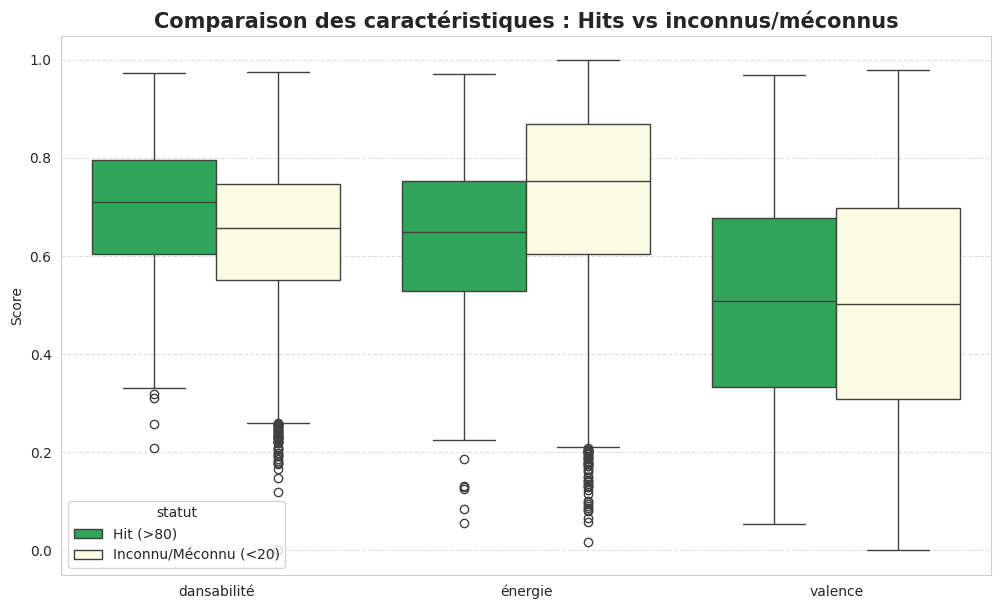

In [290]:
# On crée un nouveau DataFrame temporaire pour ne pas polluer le principal
df_comparaison = df_final[(df_final['popularité'] > 80) | (df_final['popularité'] < 20)].copy()
df_comparaison['statut'] = df_comparaison['popularité'].apply(lambda x: 'Hit (>80)' if x > 80 else 'Inconnu/Méconnu (<20)')

# On choisit les critères les plus discriminants à comparer
criteres = ['dansabilité', 'énergie', 'valence']
df_melted = df_comparaison.melt(id_vars='statut', value_vars=criteres, var_name='Caractéristique', value_name='Score')

# Tracé du diagramme en boîte
plt.figure(figsize=(12, 7))
sb.boxplot(data=df_melted, x='Caractéristique', y='Score', hue='statut', palette={'Hit (>80)': '#1DB954', 'Inconnu/Méconnu (<20)': 'lightyellow'})

plt.title('Comparaison des caractéristiques : Hits vs inconnus/méconnus', fontsize=15, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xlabel('')
plt.show()

___
___
___
(prochainement)

**ANALYSES DES GENRES DE MUSIQUE ET PREDICTION**

 - Profilage des genres de musique (pour comparer caracteristiques de chaque genre)
- Prédiction pour une chanson donnée du genre auquel il appartient